# BO Forge maximisation LogEI campaign

This notebook demonstrates the v0.2 `CampaignSession` workflow one experiment at a time.

Each cycle requests one candidate, appends it as `status=suggested`, simulates the lab result, marks that same row as `status=observed`, reloads the CSV log through the session, and only then requests the next candidate.


## 1. Setup

The example config uses a sequential campaign. The session object owns the config, log path, and current campaign DataFrame.


In [1]:
from pathlib import Path
import os
import shutil
import sys

import numpy as np
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
mpl_cache = PROJECT_ROOT / ".matplotlib-cache"
mpl_cache.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from bo_forge.session import CampaignSession


In [2]:
config_path = PROJECT_ROOT / "configs" / "simple_2d_maximise_logei.yaml"
seed_log_path = PROJECT_ROOT / "examples" / "simple_2d_maximise_logei_campaign_log.csv"
working_log_path = PROJECT_ROOT / "examples" / "simple_2d_maximise_logei_working_log.csv"
latest_suggestion_path = PROJECT_ROOT / "examples" / "simple_2d_maximise_logei_latest_suggestions.csv"
report_path = PROJECT_ROOT / "reports" / "simple_2d_maximisation_logei_campaign_report.txt"

shutil.copyfile(seed_log_path, working_log_path)

campaign = CampaignSession.from_files(config_path=config_path, log_path=working_log_path)
one_at_a_time_batch_size = 1


In [3]:
def simulated_activity(row) -> float:
    ratio = float(row["precursor_ratio"])
    temperature = float(row["annealing_temperature"])
    smooth_peak = 2.2 - 4.0 * (ratio - 0.62) ** 2
    smooth_peak -= ((temperature - 710.0) / 170.0) ** 2
    small_wave = 0.04 * np.sin(10.0 * ratio)
    small_wave += 0.03 * np.cos(temperature / 55.0)
    return float(smooth_peak + small_wave)


def current_log():
    campaign.reload()
    campaign.validate()
    return campaign.df


def request_one_candidate():
    suggestion = campaign.suggest_next(batch_size=one_at_a_time_batch_size)
    suggestion.to_csv(latest_suggestion_path, index=False)
    campaign.append_suggestions(suggestion)
    return suggestion


def enter_simulated_result(suggestion):
    row = suggestion.iloc[0]
    result = simulated_activity(row)
    campaign.mark_observed(str(row["row_id"]), result)
    return result


## 2. Load and summarise the current campaign

The campaign starts from two manually observed experiments. The remaining initial-design points will be suggested one at a time using Sobol. `campaign.next_action()` shows the recommended next notebook step.


In [4]:
campaign.validate()
print("campaign.summary():")
display(campaign.summary())
print("--"*40)
print("campaign.next_action():")
display(campaign.next_action())
print("--"*40)
campaign.df


campaign.summary():


,field,value
0,campaign_name,photocatalyst_loading
1,campaign_status,ready_for_initial_design
2,objective,activity
3,direction,maximize
4,total_rows,2
5,observed_rows,2
6,pending_suggestions,0
7,initial_design_remaining,6
8,next_iteration,1
9,best_row_id,manual_001


--------------------------------------------------------------------------------
campaign.next_action():


,campaign_status,action,reason,suggested_call
0,ready_for_initial_design,suggest_initial_design,Observed rows are below initial_design_size; r...,suggestions = campaign.suggest_next(); campaig...


--------------------------------------------------------------------------------


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,manual_000,0,observed,manual,0.2,500,1.34,,,
1,manual_001,0,observed,manual,0.7,650,1.82,,,


## 3. Request one initial candidate

In [5]:
suggestion = request_one_candidate()
print("suggestion:")
suggestion

suggestion:


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,cc4731bdca884387a4f6eec61ecdf1c9,1,suggested,sobol,0.472047,795.296508,,,,


## 4. Enter the result for that one experiment

In a real campaign, replace `simulated_activity(...)` with the measured lab result, then call `campaign.mark_observed(...)` for the same `row_id`.


In [6]:
result = enter_simulated_result(suggestion)
df = current_log()
print("Entered result:", result)
df.tail(3)

Entered result: 1.8111778742027098


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,manual_000,0,observed,manual,0.200000,500.000000,1.340000,,,
1,manual_001,0,observed,manual,0.700000,650.000000,1.820000,,,
2,cc4731bdca884387a4f6eec61ecdf1c9,1,observed,sobol,0.472047,795.296508,1.811178,,,


## 5. Repeat the same one-experiment cycle

Each cell below represents one lab iteration: suggest one candidate, run one experiment, enter one result, reload the log.

In [7]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
print("suggestion:")
display(suggestion)
print("--"*40)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

suggestion:


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,6f8c01d91001401d8a496cffbf5a6b3d,2,suggested,sobol,0.910286,478.744927,,,,


--------------------------------------------------------------------------------
Entered result: 0.002561283491411973


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
3,6f8c01d91001401d8a496cffbf5a6b3d,2,observed,sobol,0.910286,478.744927,0.002561,,,


In [8]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
print("suggestion:")
display(suggestion)
print("--"*40)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

suggestion:


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,e87bbce67244438b91c2bee1e9c56212,3,suggested,sobol,0.517631,569.10913,,,,


--------------------------------------------------------------------------------
Entered result: 1.4173397552958444


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
4,e87bbce67244438b91c2bee1e9c56212,3,observed,sobol,0.517631,569.10913,1.41734,,,


In [9]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
display(suggestion)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,022340bb96a444f79be2bedf35ec005f,4,suggested,sobol,0.083311,393.470521,,,,


Entered result: -2.3700258156251692


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
5,022340bb96a444f79be2bedf35ec005f,4,observed,sobol,0.083311,393.470521,-2.370026,,,


In [10]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
print("suggestion:")
display(suggestion)
print("--"*40)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

suggestion:


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,d98110ec839943e5b1333f2d19856ca9,5,suggested,sobol,0.203096,674.482185,,,,


--------------------------------------------------------------------------------
Entered result: 1.5255866339657844


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
6,d98110ec839943e5b1333f2d19856ca9,5,observed,sobol,0.203096,674.482185,1.525587,,,


In [11]:
suggestion = request_one_candidate()
result = enter_simulated_result(suggestion)
df = current_log()
print("suggestion:")
display(suggestion)
print("--"*40)
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

suggestion:


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,a2a13814009543e8b3823201a1dd6ab7,6,suggested,sobol,0.633526,350.169606,,,,


--------------------------------------------------------------------------------
Entered result: -2.2489590768214742


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
7,a2a13814009543e8b3823201a1dd6ab7,6,observed,sobol,0.633526,350.169606,-2.248959,,,


## 6. Now the initial design is complete

Once the number of observed rows reaches `initial_design_size`, the next session suggestion fits the GP and uses LogEI because this notebook requests one candidate at a time.


In [12]:
len(campaign.observed_data()), campaign.config.bo.initial_design_size

(8, 8)

In [13]:
suggestion = request_one_candidate()
print("suggestion:")
display(suggestion)
print("--"*40)

suggestion:


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,ea21467305254d99b00710e133badae9,7,suggested,log_ei,1.0,723.627666,,1.96824,0.923904,-0.804216


--------------------------------------------------------------------------------


In [14]:
result = enter_simulated_result(suggestion)
df = current_log()
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

Entered result: 1.619133028587096


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
8,ea21467305254d99b00710e133badae9,7,observed,log_ei,1.0,723.627666,1.619133,1.9682399455886144,0.9239038565971786,-0.8042160487324732


In [15]:
suggestion = request_one_candidate()
print("suggestion:")
display(suggestion)
print("--"*40)

suggestion:


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
0,8074a14c0ce74a19aaa022a85147079b,8,suggested,log_ei,0.0,800.0,,1.753559,0.434705,-1.950357


--------------------------------------------------------------------------------


In [16]:
result = enter_simulated_result(suggestion)
df = current_log()
print("Entered result:", result)
df.loc[df["row_id"] == str(suggestion.loc[0, "row_id"])]

Entered result: 0.37021203527365537


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,activity,predicted_mean,predicted_std,acquisition
9,8074a14c0ce74a19aaa022a85147079b,8,observed,log_ei,0.0,800.0,0.370212,1.753558627755416,0.43470510270173296,-1.950357161425289


## 7. Diagnostics

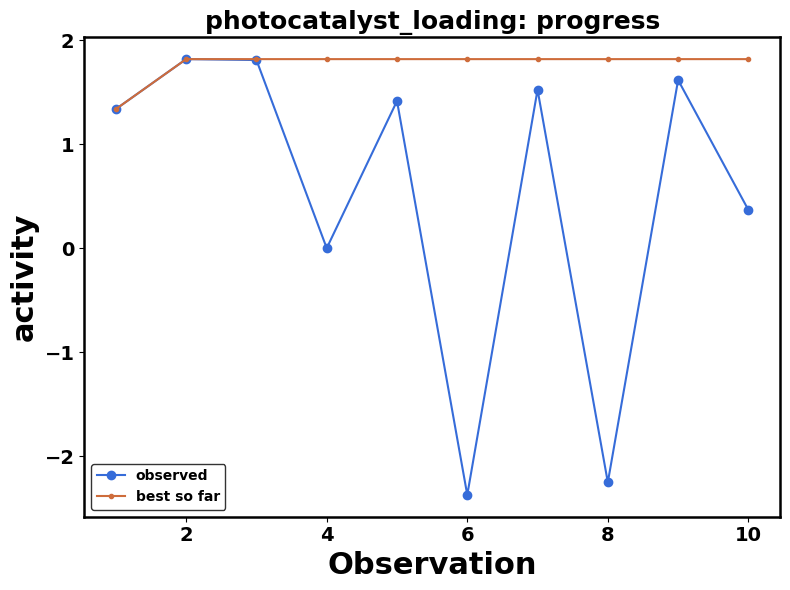

In [17]:
campaign.plot_progress();

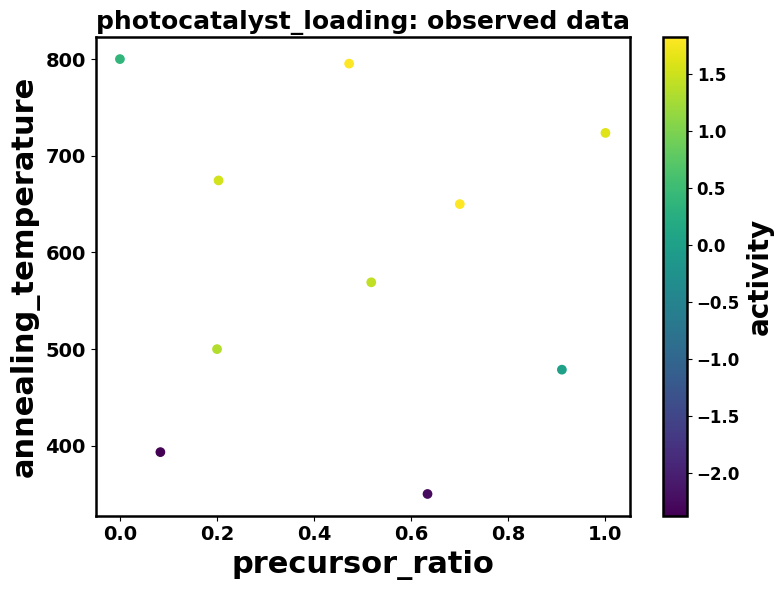

In [18]:
campaign.plot_diagnostics();

## 8. Reports

In [19]:
campaign.report()

{'summary':                        field                  value
 0              campaign_name  photocatalyst_loading
 1            campaign_status           ready_for_bo
 2                  objective               activity
 3                  direction               maximize
 4                 total_rows                     10
 5              observed_rows                     10
 6        pending_suggestions                      0
 7   initial_design_remaining                      0
 8             next_iteration                      9
 9                best_row_id             manual_001
 10      best_objective_value                   1.82,
 'next_action':   campaign_status      action  \
 0    ready_for_bo  suggest_bo   
 
                                               reason  \
 0  Initial design is complete and no pending sugg...   
 
                                       suggested_call  
 0  suggestions = campaign.suggest_next(batch_size...  ,
 'best_observation':        row_id  it

In [20]:
campaign.export_report(report_path)

PosixPath('/Users/liangze/Desktop/bo_forge/reports/simple_2d_maximisation_logei_campaign_report.txt')